### 9 - LinearSVC, SVC e SGDClassifier

Exercício: treine um `LinearSVC` em um conjunto de dados linearmente separável. Depois, treine um `SVC` e um `SGDClassifier` no mesmo conjunto de dados. Veja se consegue fazer com que eles produzam aproximadamente o mesmo modelo.


In [4]:
import sys
from packaging import version

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.datasets import load_iris
from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC, SVC

assert sys.version_info >= (3, 7)
assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

np.random.seed(42)


Vamos usar o conjunto Iris com apenas duas classes (`setosa` e `versicolor`) e dois atributos (`petal length` e `petal width`). Essas duas classes são linearmente separáveis nesse espaço.


In [5]:
iris = load_iris(as_frame=True)

X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = iris.target.values

setosa_or_versicolor = (y == 0) | (y == 1)
X = X[setosa_or_versicolor]
y = y[setosa_or_versicolor].astype(np.float64)

iris.target_names[:2], X.shape, np.bincount(y.astype(int))


(array(['setosa', 'versicolor'], dtype='<U10'), (100, 2), array([50, 50]))

Como SVMs são sensíveis à escala dos atributos, os três modelos serão treinados com `StandardScaler`. Para aproximar os modelos, todos usam perda `hinge` e regularização comparável.

No `SGDClassifier`, o parâmetro equivalente a `C` aparece por meio de `alpha`. Uma aproximação comum é usar `alpha = 1 / (C * m)`, em que `m` é o número de instâncias de treino.


In [6]:
C = 5
m = len(X)

linear_svc = make_pipeline(
    StandardScaler(),
    LinearSVC(C=C, loss="hinge", dual=True, random_state=42, max_iter=100_000),
)

svc = make_pipeline(
    StandardScaler(),
    SVC(kernel="linear", C=C),
)

sgd_clf = make_pipeline(
    StandardScaler(),
    SGDClassifier(
        loss="hinge",
        alpha=1 / (C * m),
        learning_rate="constant",
        eta0=0.001,
        max_iter=100_000,
        tol=1e-6,
        random_state=42,
    ),
)

models = {
    "LinearSVC": linear_svc,
    "SVC(kernel='linear')": svc,
    "SGDClassifier": sgd_clf,
}

for model in models.values():
    model.fit(X, y)


Para comparar os modelos de forma justa, convertemos os coeficientes aprendidos no espaço escalonado de volta para o espaço original dos atributos.


In [7]:
def original_space_params(model):
    scaler = model[0]
    classifier = model[1]
    scaled_coef = classifier.coef_[0]
    scaled_intercept = classifier.intercept_[0]

    coef = scaled_coef / scaler.scale_
    intercept = scaled_intercept - np.dot(scaled_coef, scaler.mean_ / scaler.scale_)
    return coef, intercept


rows = []
for name, model in models.items():
    coef, intercept = original_space_params(model)
    rows.append(
        {
            "modelo": name,
            "acuracia": model.score(X, y),
            "coef_petala_comprimento": coef[0],
            "coef_petala_largura": coef[1],
            "intercepto": intercept,
        }
    )

comparison = pd.DataFrame(rows).set_index("modelo")
comparison.round(4)


,acuracia,coef_petala_comprimento,coef_petala_largura,intercepto
modelo,,,,
LinearSVC,1.0,0.7305,1.9545,-3.3415
SVC(kernel='linear'),1.0,0.7768,1.8250,-3.3379
SGDClassifier,1.0,0.7710,1.8432,-3.3397


Visualmente, as três fronteiras de decisão ficam muito próximas.


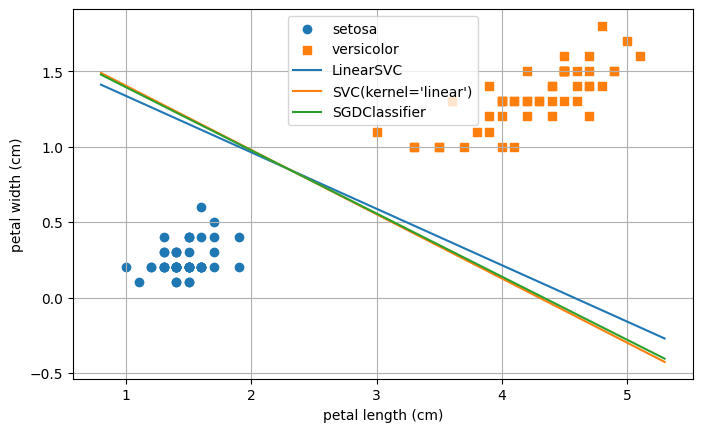

In [8]:
x0 = np.linspace(X[:, 0].min() - 0.2, X[:, 0].max() + 0.2, 200)

plt.figure(figsize=(8, 4.8))
plt.scatter(X[y == 0, 0], X[y == 0, 1], label="setosa", marker="o")
plt.scatter(X[y == 1, 0], X[y == 1, 1], label="versicolor", marker="s")

for name, model in models.items():
    coef, intercept = original_space_params(model)
    x1 = -(coef[0] * x0 + intercept) / coef[1]
    plt.plot(x0, x1, label=name)

plt.xlabel("petal length (cm)")
plt.ylabel("petal width (cm)")
plt.legend()
plt.grid(True)
plt.show()


O `LinearSVC` e o `SVC(kernel="linear")` chegam a fronteiras quase idênticas. O `SGDClassifier` também encontra uma fronteira muito parecida, mas pode variar um pouco porque usa descida do gradiente estocástica e é mais sensível a `alpha`, `eta0`, `max_iter` e `tol`.

A conclusão principal é que os três estimadores conseguem representar uma SVM linear. Para que produzam modelos aproximadamente equivalentes, precisamos usar dados escalonados, perda `hinge` e níveis de regularização comparáveis.
